## Fitting classifiers

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn import set_config
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import pickle
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
original_df = pd.read_csv('tracks2026.csv')
df = original_df.copy()
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [3]:
# Drop NaN values and trackid
df = df.dropna()
df = df.drop(columns = ["track_id"])
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [4]:
# Replacing explicit with ones and zeros
scale_mapper = {
    False: 0,
    True: 1,
}
# One hot encoding track_genre
# TODO ? Should one hot encoding be done before the split to train and test? Basically, should we involve it to pipelines?

df = pd.get_dummies(df, columns=['track_genre'],
                        drop_first=True)
df[['explicit', 'track_genre_indie-pop', 'track_genre_pop', 'track_genre_r-n-b', 'track_genre_synth-pop']] = df[['explicit', 'track_genre_indie-pop', 'track_genre_pop', 'track_genre_r-n-b', 'track_genre_synth-pop']].replace(scale_mapper)
df

C:\Users\pette\AppData\Local\Temp\ipykernel_21768\948614614.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['explicit', 'track_genre_indie-pop', 'track_genre_pop', 'track_genre_r-n-b', 'track_genre_synth-pop']] = df[['explicit', 'track_genre_indie-pop', 'track_genre_pop', 'track_genre_r-n-b', 'track_genre_synth-pop']].replace(scale_mapper)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,0,0,1,0
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,0,1,0,0
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,0,0,0,1
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,1,0,0,0
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,0,0,0,1
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,0,0,0,1
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,1,0,0,0
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,0,0,0,0


In [5]:
# Encode
map_cat = {False: 0, True: 1}
df[['explicit','track_genre_indie-pop','track_genre_pop','track_genre_r-n-b','track_genre_synth-pop']] = df[['explicit','track_genre_indie-pop','track_genre_pop','track_genre_r-n-b','track_genre_synth-pop']].replace(map_cat)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,0,0,1,0
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,0,1,0,0
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,0,0,0,1
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,1,0,0,0
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,0,0,0,1
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,0,0,0,1
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,1,0,0,0
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,0,0,0,0


In [6]:
# New target variable. This could be seen as a data leak, but as median is global and quite robust, we can the median of the whole dataset.
median_popularity = df["popularity"].median()
df['popularity_binary'] = df["popularity"].apply(lambda x: 0 if x <= median_popularity else 1)
df = df.drop(columns=["popularity"])
# X and y
y = df['popularity_binary']
X = df.drop(columns=["popularity_binary"])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [7]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p)),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p)),
     ('scaler', RobustScaler())
])
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, ["key", "time_signature"])
    ],
    remainder='drop'
)


In [8]:
# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

In [9]:
# SVM
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("svm", svm.SVC(probability=True))])

# Parameter grid
param_grid = {
    'svm__C': [0.1],
    'svm__gamma': [1],
    'svm__kernel': ['linear']
}

# Note that hyperparameters of the preprocessing transformers can also be included
# in the parameter grid. For simplicity, we do not tune them here.

svm_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
svm_search.fit(X_train, y_train) 

print(f"Best CV F1 = {svm_search.best_score_:.3f}")
print("Best parameters: ", svm_search.best_params_)

# store the best params and best model for later use
SVM_best_params = svm_search.best_params_
SVM_best_model = svm_search.best_estimator_
SVM_best_cv_f1 = svm_search.best_score_

Best CV F1 = 0.656
Best parameters:  {'svm__C': 0.1, 'svm__gamma': 1, 'svm__kernel': 'linear'}


In [10]:
# Random forest
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("r_forest", RandomForestClassifier())])
# Parameter grid
param_grid = {
    'r_forest__n_estimators': [10, 20, 30, 40],
    'r_forest__max_depth': [2, 4, 6, 8, 10, 12]
}

r_forest_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
r_forest_search.fit(X_train, y_train) 

print(f"Best CV F1 = {r_forest_search.best_score_:.3f}")
print("Best parameters: ", r_forest_search.best_params_)

# store the best params and best model for later use
r_forest_best_params = r_forest_search.best_params_
r_forest_best_model = r_forest_search.best_estimator_
r_forest_best_cv_f1 = r_forest_search.best_score_

Best CV F1 = 0.720
Best parameters:  {'r_forest__max_depth': 10, 'r_forest__n_estimators': 30}


In [11]:
# Gaussian (Normal) Naive Bayes
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("naive_bayes", GaussianNB())])
# Parameter grid
param_grid = {
    'naive_bayes__var_smoothing': [0.00000001, 0.00001, 0.001, 0.1]
}

NB_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
NB_search.fit(X_train, y_train) 

print(f"Best CV F1 = {NB_search.best_score_:.3f}")
print("Best parameters: ", NB_search.best_params_)

# store the best params and best model for later use
NB_best_params = NB_search.best_params_
NB_best_model = NB_search.best_estimator_
NB_best_cv_f1 = NB_search.best_score_

Best CV F1 = 0.642
Best parameters:  {'naive_bayes__var_smoothing': 1e-08}


In [12]:
# Copied from the lab-exercise
# Compute CV metrics (mean ± std) for the *best* SVM, random forest and naive bayes models
models = {
    "SVM (best by F1)": SVM_best_model,
    "Random Forest (best by F1)": r_forest_best_model,
    "Gaussian Naive Bayes (best by F1)": NB_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

# Print a concise summary
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")




SVM (best by F1)
  F1-score : mean=0.656, std=0.023
  Precision: mean=0.582, std=0.022
  Recall   : mean=0.754, std=0.049
  ROC_AUC  : mean=0.646, std=0.035
  AP       : mean=0.619, std=0.048

Random Forest (best by F1)
  F1-score : mean=0.711, std=0.033
  Precision: mean=0.696, std=0.044
  Recall   : mean=0.728, std=0.042
  ROC_AUC  : mean=0.766, std=0.037
  AP       : mean=0.752, std=0.046

Gaussian Naive Bayes (best by F1)
  F1-score : mean=0.642, std=0.032
  Precision: mean=0.594, std=0.032
  Recall   : mean=0.700, std=0.045
  ROC_AUC  : mean=0.656, std=0.040
  AP       : mean=0.629, std=0.037


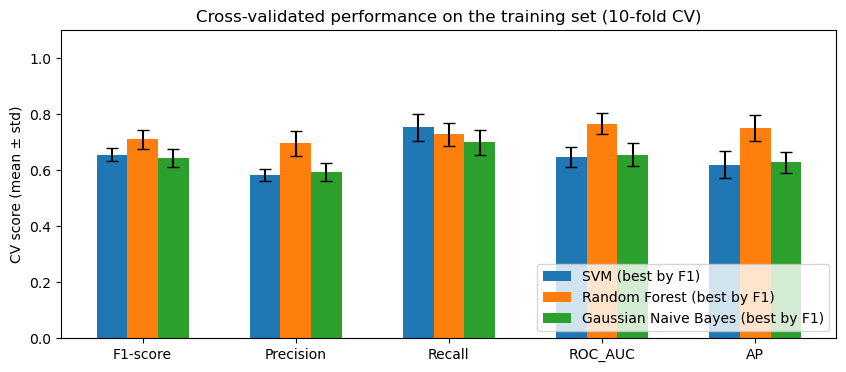

In [13]:
# Copied from the lab-exercise
# Plot of the mean and std of the metrics of different classifiers
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

# means and stds
means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x , means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.bar(x + width, means[labels[2]], width, yerr=stds[labels[2]], capsize=4, label=labels[2])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()


### ROC curve

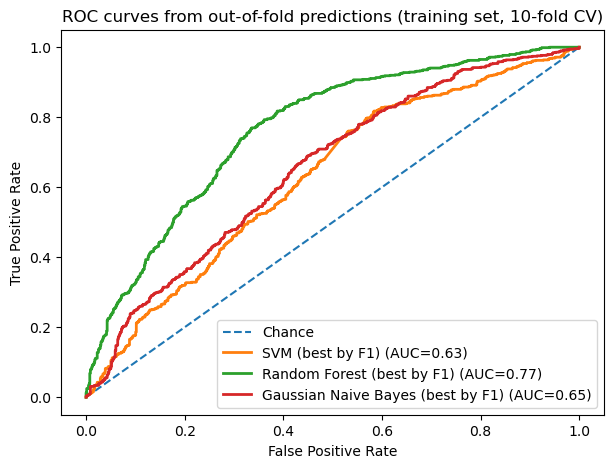

In [14]:
# Copied from the lab-exercise
# Out-of-fold ROC curves for the two best models (training set only)
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in models.items():
    # Out-of-fold probability for class 1 (each point predicted by a model that did not train on it)
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()


### Evaluation by exercise notebook

In [15]:
best_model = r_forest_best_model
best_name = "Random Forest"
best_cv_f1 = r_forest_best_cv_f1

In [16]:
# Copied from the lab-exercise
def evaluate_model(X_eval, y_eval, model):
    # predicted probabilities for class 1
    probabilities = model.predict_proba(X_eval)[:, 1]

    # predicted class labels
    predicted = model.predict(X_eval)

    # confusion matrix
    cm = confusion_matrix(y_eval, predicted)

    # metrics
    acc = accuracy_score(y_eval, predicted)
    prec = precision_score(y_eval, predicted, zero_division=0)
    rec = recall_score(y_eval, predicted, zero_division=0)
    f1 = f1_score(y_eval, predicted, zero_division=0)

    # ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    auc_val = auc(fpr, tpr)

    # PR curve + average_precision
    prc_precision, prc_recall, _ = precision_recall_curve(y_eval, probabilities)
    prc_ap = average_precision_score(y_eval, probabilities)

    return cm, acc, prec, rec, f1, fpr, tpr, auc_val, prc_precision, prc_recall, prc_ap
# Final evaluation on the held-out test set (used once for reporting)
test_cm, test_accuracy, test_precision, test_recall, test_f1_score, test_fpr, test_tpr, test_auc, test_prc_precision, test_prc_recall, test_prc_ap = evaluate_model(X_test, y_test, best_model)
cm_df = pd.DataFrame(
    test_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix (Test Set):")
display(cm_df)

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,129,70
Actual 1,61,132


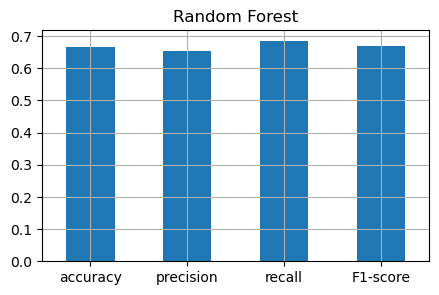

In [17]:
# Copied from the lab-exercise
metrics = np.array([test_accuracy, test_precision, test_recall, test_f1_score])
index = ['accuracy', 'precision', 'recall', 'F1-score']
df_metrics = pd.DataFrame({best_name: metrics}, index=index)
df_metrics.plot.bar(rot=0, figsize=(5, 3), legend=False, title=f"{best_name}")
plt.grid()
plt.show()

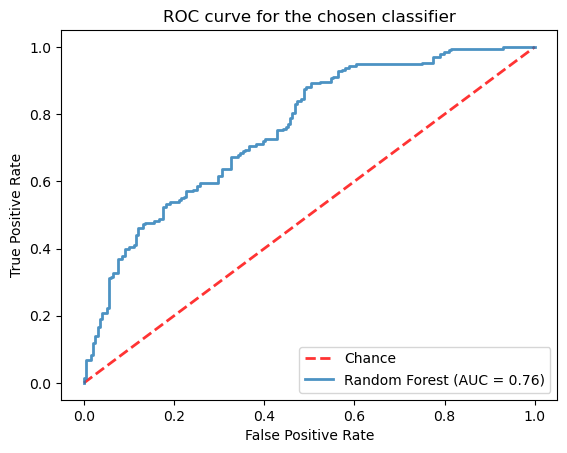

In [18]:
# Copied from the lab-exercise
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
plt.plot(test_fpr, test_tpr, lw=2, label=f'{best_name} (AUC = {test_auc:0.2f})', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for the chosen classifier')
plt.legend(loc="lower right")
plt.show()
